In [2]:
!pip install ucimlrepo

In [3]:
#pip install prettytable
# Install mlxtend for association mining
!pip install mlxtend

In [4]:
#libraries
from ucimlrepo import fetch_ucirepo
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import numpy as np


# Import necessary libraries
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.frequent_patterns import fpgrowth

In [5]:
# fetch dataset
online_retail = fetch_ucirepo(id=352)

# data (as pandas dataframes)
x = online_retail.data.features
y = online_retail.data.targets
z = online_retail.data.ids


In [6]:
df = pd.concat([z, x], axis=1)

In [7]:
df = df.drop(columns=['Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10'], errors='ignore')

# Data Preprocessing


In [8]:
df_ver001 = df.copy()
df_ver002 = df_ver001.copy ()

In [9]:

# Assuming 'InvoiceDate' is the column containing date and time information
df_ver001['InvoiceDate'] = pd.to_datetime(df_ver001['InvoiceDate'])
df_ver001['Date'] = df_ver001['InvoiceDate'].dt.date
df_ver001['Time'] = df_ver001['InvoiceDate'].dt.time
df_ver001


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Date,Time
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,08:26:00
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01,08:26:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,2011-12-09,12:50:00
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,2011-12-09,12:50:00
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,2011-12-09,12:50:00
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,2011-12-09,12:50:00


In [10]:
df_ver001.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
 8   Date         541909 non-null  object        
 9   Time         541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 41.3+ MB


In [11]:
df_ver001.shape #number of rows and columns

(541909, 10)

In [12]:
df_ver001['Country'].describe() # 38 unique countries

,Country
count,541909
unique,38
top,United Kingdom
freq,495478


In [13]:
df_ver001['StockCode'].describe() # 4070 unique items

,StockCode
count,541909
unique,4070
top,85123A
freq,2313


In [14]:
df_ver001['Description'].describe() # 4223 item names disclosed

,Description
count,540455
unique,4223
top,WHITE HANGING HEART T-LIGHT HOLDER
freq,2369


In [15]:
df_ver001['InvoiceNo'].nunique() # number of unique transactions

25900

In [16]:
df_ver001['CustomerID'].nunique() # number of customers

4372

In [17]:
df_ver001[['StockCode', 'Description', 'CustomerID']] #StockCode, Description and Customer ID together

,StockCode,Description,CustomerID
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17850.0
1,71053,WHITE METAL LANTERN,17850.0
2,84406B,CREAM CUPID HEARTS COAT HANGER,17850.0
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,17850.0
4,84029E,RED WOOLLY HOTTIE WHITE HEART.,17850.0
...,...,...,...
541904,22613,PACK OF 20 SPACEBOY NAPKINS,12680.0
541905,22899,CHILDREN'S APRON DOLLY GIRL,12680.0
541906,23254,CHILDRENS CUTLERY DOLLY GIRL,12680.0
541907,23255,CHILDRENS CUTLERY CIRCUS PARADE,12680.0


In [18]:
pd.isnull(df_ver001['CustomerID']).sum() #check missing values for CustomerID

np.int64(135080)

In [19]:
# Drop rows with any missing values
df_ver001_cleaned = df_ver001.dropna()

# Display the new count of rows
print("New row count:", len(df_ver001_cleaned))

New row count: 406829


In [20]:
df_ver001 = df_ver001_cleaned

# Group by 'CustomerID' and 'InvoiceNo', summing 'Quantity' and 'Price'
df_ver001_grouped = df_ver001.groupby(['CustomerID', 'InvoiceNo'], as_index=False).agg({
    'Quantity': 'sum',
    'UnitPrice': 'sum'
})

# Display the first few rows
print(df_ver001_grouped.head())
#df_ver001

   CustomerID InvoiceNo  Quantity  UnitPrice
0     12346.0    541431     74215       1.04
1     12346.0   C541433    -74215       1.04
2     12347.0    537626       319      89.59
3     12347.0    542237       315      73.17
4     12347.0    549222       483      62.29


In [21]:
# Filter out cancellations
filtered_df = df_ver001[df_ver001['InvoiceNo'].str.contains('C', na=False)]
grouped_df = filtered_df.groupby('CustomerID')['InvoiceNo'].apply(list)
#print(grouped_df)
grouped_df



,InvoiceNo
CustomerID,
12346.0,[C541433]
12352.0,"[C545329, C545329, C545330, C547388, C547388, ..."
12359.0,"[C549955, C549955, C580165, C580165, C580165, ..."
12362.0,"[C544902, C544902, C563752, C563752, C563752, ..."
12365.0,[C544577]
...,...
18272.0,"[C552720, C552720, C552720, C552720]"
18274.0,"[C577832, C577832, C577832, C577832, C577832, ..."
18276.0,"[C577386, C577390]"


In [22]:
# Top 5 customers with the most cancellations
top_cancellations = grouped_df.apply(len).sort_values(ascending=False)
print(top_cancellations)
#top_cancellations

CustomerID
14911.0    226
17841.0    136
17511.0    113
15311.0    112
12607.0    101
          ... 
18177.0      1
18164.0      1
18161.0      1
12423.0      1
12505.0      1
Name: InvoiceNo, Length: 1589, dtype: int64


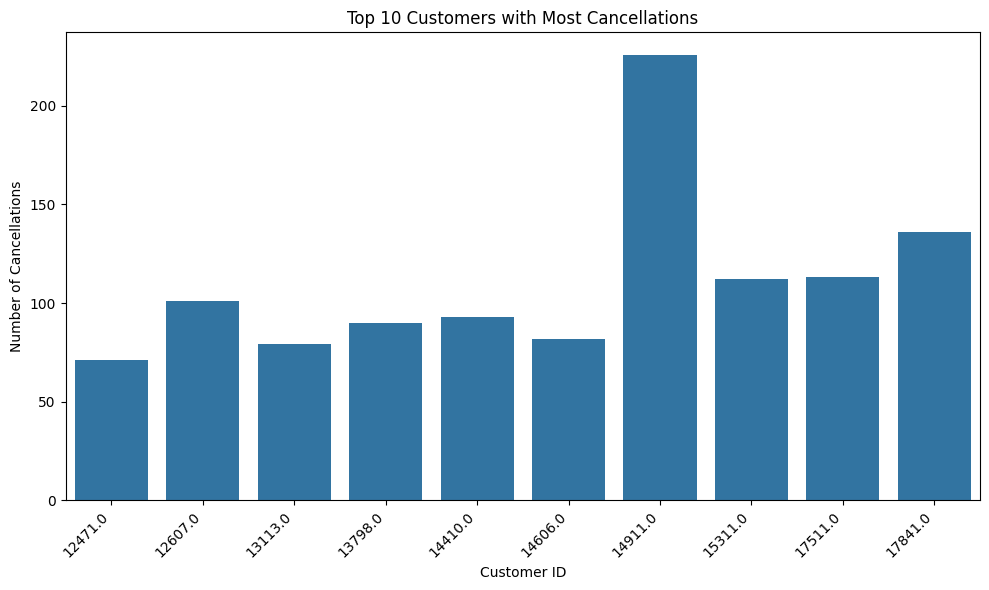

In [23]:
#  top 10 cancellations
plt.figure(figsize=(10, 6))
sns.barplot(x=top_cancellations.head(10).index, y=top_cancellations.head(10).values)
plt.xlabel("Customer ID")
plt.ylabel("Number of Cancellations")
plt.title("Top 10 Customers with Most Cancellations")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


In [24]:
grouped_df.describe()

,InvoiceNo
count,1589
unique,1589
top,[C562808]
freq,1


In [25]:
merged_df = grouped_df.reset_index().merge(df_ver001[['CustomerID', 'Country']], on='CustomerID', how='left')
country_counts = merged_df.groupby('Country').size()
print(country_counts)

Country
Australia               1034
Austria                  112
Belgium                 1286
Channel Islands          599
Cyprus                   280
Czech Republic            30
Denmark                  147
EIRE                    7485
European Community        61
Finland                  446
France                  5353
Germany                 7719
Greece                    56
Israel                     2
Italy                    517
Japan                    301
Malta                     82
Netherlands             2229
Norway                   186
Poland                   248
Portugal                 628
Saudi Arabia              10
Singapore                229
Spain                   1817
Sweden                   325
Switzerland             1119
USA                      224
United Kingdom        221267
dtype: int64


In [26]:
df_ver002.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [27]:
df_ver002 = df_ver001[~df_ver001['InvoiceNo'].isin(filtered_df['InvoiceNo'])]

df_ver002.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      397924 non-null  object        
 8   Date         397924 non-null  object        
 9   Time         397924 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 33.4+ MB


In [28]:
df_ver002['CustomerID']=df_ver002['CustomerID'].astype(object)
df_ver002.info()

<ipython-input-28-4f78b4350ce6>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ver002['CustomerID']=df_ver002['CustomerID'].astype(object)


<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  object        
 7   Country      397924 non-null  object        
 8   Date         397924 non-null  object        
 9   Time         397924 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(7)
memory usage: 33.4+ MB


In [29]:
df_ver002.StockCode.unique()

array(['85123A', '71053', '84406B', ..., '90214Z', '90089', '23843'],
      dtype=object)

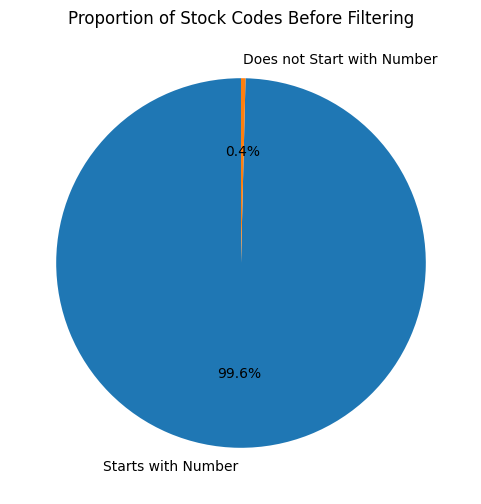

In [30]:
# Before Filtering
before_counts = df_ver002['StockCode'].str.match(r'^\d').value_counts()
labels = ['Starts with Number', 'Does not Start with Number']
plt.figure(figsize=(6, 6))
plt.pie(before_counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Stock Codes Before Filtering')
plt.show()

In [31]:
import re

# Check if any StockCode starts with a number
def starts_with_number(input_string):
  return bool(re.match(r'^\d', str(input_string)))

# Removed any StockCodes that do not start with a number
df_ver002 = df_ver002[df_ver002['StockCode'].apply(starts_with_number)]


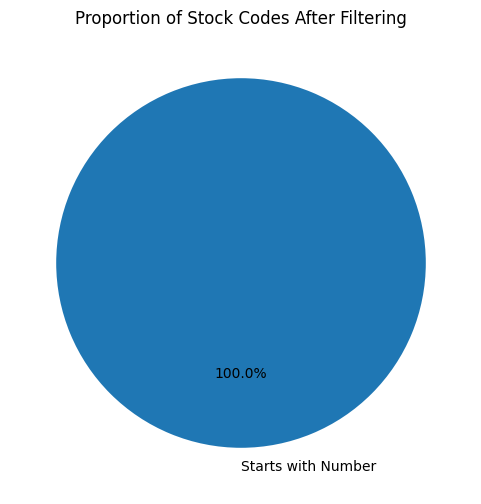

In [32]:
# After Filtering
after_counts = df_ver002[df_ver002['StockCode'].str.match(r'^\d')]['StockCode'].str.match(r'^\d').value_counts()
plt.figure(figsize=(6, 6))
plt.pie(after_counts, labels=['Starts with Number'], autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Stock Codes After Filtering')
plt.show()

In [33]:
# Removed the 'InvoiceDate' column
if 'InvoiceDate' in df_ver002.columns:
  df_ver002 = df_ver002.drop('InvoiceDate', axis=1)

df_ver002


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,2010-12-01,08:26:00
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,2010-12-01,08:26:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,12680.0,France,2011-12-09,12:50:00
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,France,2011-12-09,12:50:00
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,France,2011-12-09,12:50:00
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680.0,France,2011-12-09,12:50:00


In [34]:
# a new column Total dictated by quantity * unit price

df_ver002['Total'] = df_ver002['Quantity'] * df_ver002['UnitPrice']
df_ver002


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time,Total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,2010-12-01,08:26:00,15.30
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,2010-12-01,08:26:00,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,12680.0,France,2011-12-09,12:50:00,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,France,2011-12-09,12:50:00,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,France,2011-12-09,12:50:00,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680.0,France,2011-12-09,12:50:00,16.60


In [35]:
# a new table that sums all totals and quantities under the same invoice number.
# keeping date, time, and customer columns

df_ver003 = df_ver002.groupby(['CustomerID', 'InvoiceNo', 'Date', 'Time'], as_index=False)['Total'].sum()

df_ver003 = df_ver003.rename(columns={'Total': 'Total Spent per InvoiceNo'})

df_ver003


,CustomerID,InvoiceNo,Date,Time,Total Spent per InvoiceNo
0,12346.0,541431,2011-01-18,10:01:00,77183.60
1,12347.0,537626,2010-12-07,14:57:00,711.79
2,12347.0,542237,2011-01-26,14:30:00,475.39
3,12347.0,549222,2011-04-07,10:43:00,636.25
4,12347.0,556201,2011-06-09,13:01:00,382.52
...,...,...,...,...,...
18430,18283.0,579673,2011-11-30,12:59:00,223.61
18431,18283.0,580872,2011-12-06,12:02:00,208.00
18432,18287.0,554065,2011-05-22,10:39:00,765.28
18433,18287.0,570715,2011-10-12,10:23:00,1001.32


In [36]:
# Calculated the mean of 'Total Spent per InvoiceNo'
mean_total_spent = df_ver003['Total Spent per InvoiceNo'].mean()
print(f"Mean Total Spent per InvoiceNo: {mean_total_spent}")

# Calculated the median of 'Total Spent per InvoiceNo'
median_total_spent = df_ver003['Total Spent per InvoiceNo'].median()
print(f"Median Total Spent per InvoiceNo: {median_total_spent}")


Mean Total Spent per InvoiceNo: 475.24093572009764
Median Total Spent per InvoiceNo: 302.0


The outlier_table contains rows for each outlier, with columns indicating the feature name and the corresponding outlier values.

<Axes: >

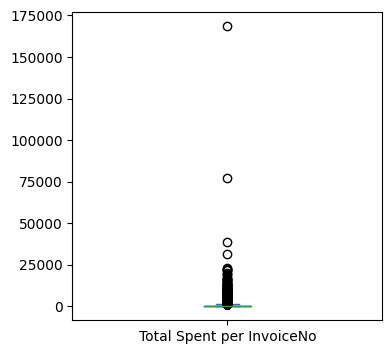

In [37]:
#checking for outliers
fig, ax = plt.subplots(figsize=(4, 4))
df_ver003['Total Spent per InvoiceNo'].plot.box(whis = 3)


<Axes: ylabel='Density'>

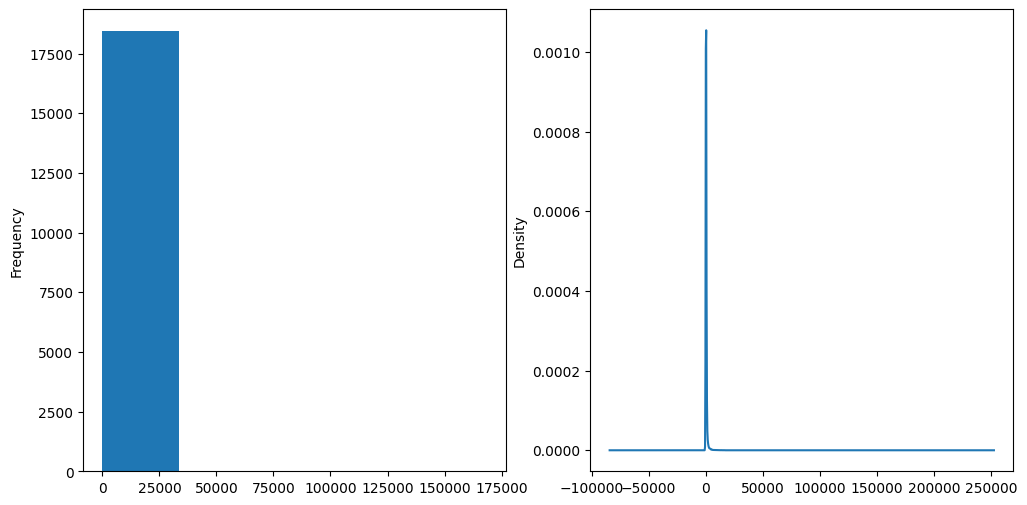

In [38]:
%matplotlib inline

fig,ax= plt.subplots(1,2, figsize =(12,6))
df_ver003['Total Spent per InvoiceNo'].plot.hist(bins=5, ax=ax[0])
df_ver003['Total Spent per InvoiceNo'].plot.density(ax=ax[1])

In [39]:
def check_outliers(x, factor):
  q25 = x.quantile(0.25)
  q75 = x.quantile(0.75)
  iqr = q75 - q25
  l = q25 - iqr * factor
  u = q75 + iqr * factor
  return l, u

  lower,upper = check_outliers(df_ver003['Total Spent per InvoiceNo'], 1.5)
  print(lower, upper)

In [40]:
lower,upper = check_outliers(df_ver003['Total Spent per InvoiceNo'], 1.5)
print(lower, upper)

-303.2675 925.5525


In [41]:
mask_lower = df_ver003['Total Spent per InvoiceNo'] < lower
mask_lower.sum()

np.int64(0)

In [42]:
mask_upper = df_ver003['Total Spent per InvoiceNo'] > upper
mask_upper.sum()

np.int64(1462)

In [43]:
df_ver003['replace_total'] = df_ver003['Total Spent per InvoiceNo'].map(lambda x: upper if x> upper else lower if x < lower else x)


<Axes: >

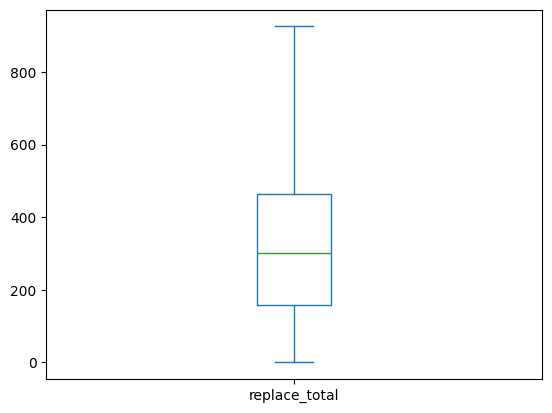

In [44]:
df_ver003['replace_total'].plot.box(whis=1.5)

<Axes: >

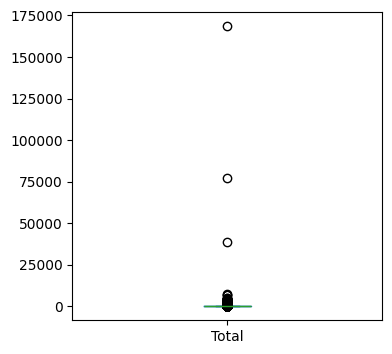

In [45]:
#checking for outliers
fig, ax = plt.subplots(figsize=(4, 4))
df_ver002['Total'].plot.box(whis = 3)

<Axes: ylabel='Density'>

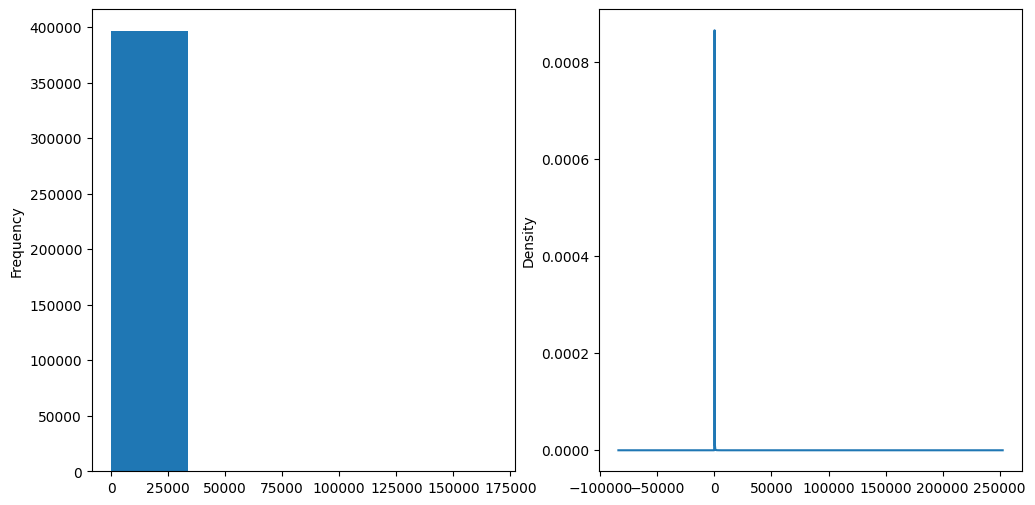

In [46]:
%matplotlib inline

fig,ax= plt.subplots(1,2, figsize =(12,6))
df_ver002['Total'].plot.hist(bins=5, ax=ax[0])
df_ver002['Total'].plot.density(ax=ax[1])

-17.999999999999996 42.47999999999999


<Axes: >

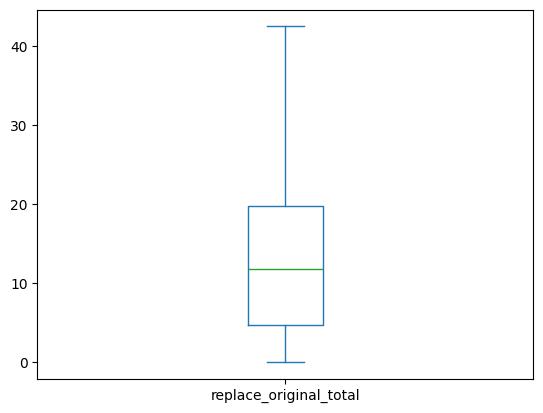

In [47]:
lower,upper = check_outliers(df_ver002['Total'], 1.5)
print(lower, upper)

mask_lower = df_ver002['Total'] < lower
mask_lower.sum()

mask_upper = df_ver002['Total'] > upper
mask_upper.sum()

df_ver002['replace_original_total'] = df_ver002['Total'].map(lambda x: upper if x> upper else lower if x < lower else x)
df_ver002['replace_original_total'].plot.box(whis=1.5)


<Axes: >

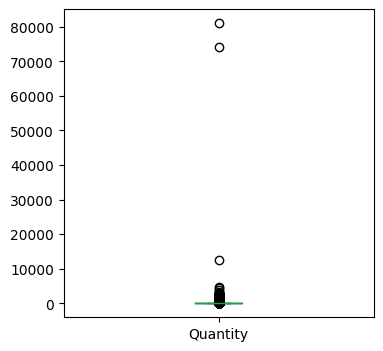

In [48]:
#checking for outliers
fig, ax = plt.subplots(figsize=(4, 4))
df_ver002['Quantity'].plot.box(whis = 3)

<Axes: ylabel='Density'>

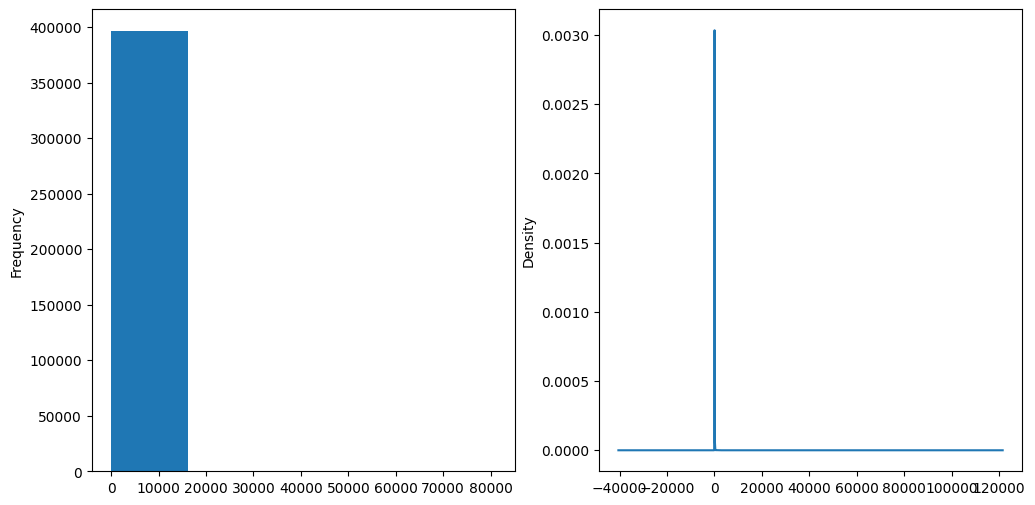

In [49]:
%matplotlib inline

fig,ax= plt.subplots(1,2, figsize =(12,6))
df_ver002['Quantity'].plot.hist(bins=5, ax=ax[0])
df_ver002['Quantity'].plot.density(ax=ax[1])

-13.0 27.0


<Axes: >

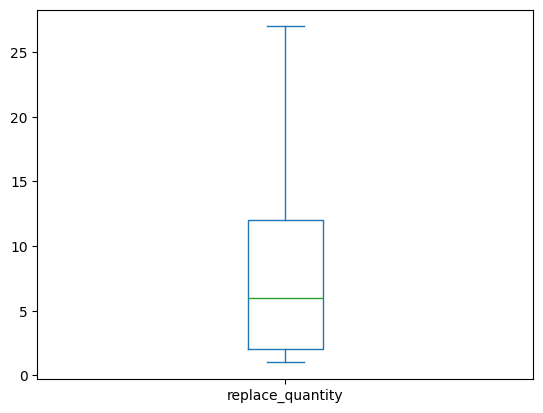

In [50]:
lower,upper = check_outliers(df_ver002['Quantity'], 1.5)
print(lower, upper)

mask_lower = df_ver002['Quantity'] < lower
mask_lower.sum()

mask_upper = df_ver002['Quantity'] > upper
mask_upper.sum()

df_ver002['replace_quantity'] = df_ver002['Quantity'].map(lambda x: upper if x> upper else lower if x < lower else x)
df_ver002['replace_quantity'].plot.box(whis=1.5)

<Axes: >

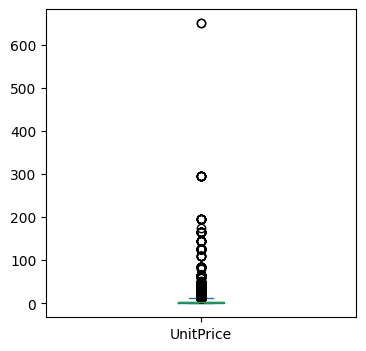

In [51]:
#checking for outliers
fig, ax = plt.subplots(figsize=(4, 4))
df_ver002['UnitPrice'].plot.box(whis = 3)

<Axes: ylabel='Density'>

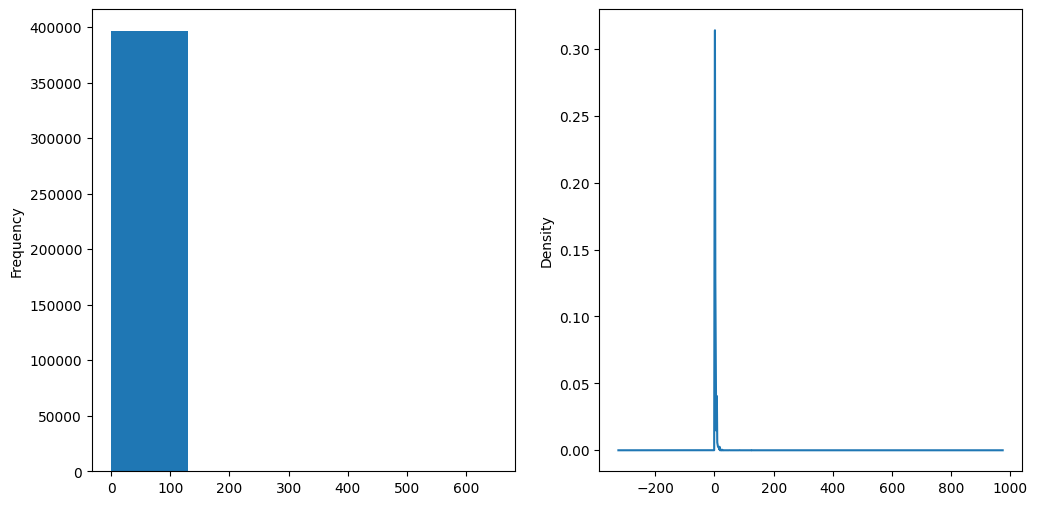

In [52]:
%matplotlib inline

fig,ax= plt.subplots(1,2, figsize =(12,6))
df_ver002['UnitPrice'].plot.hist(bins=5, ax=ax[0])
df_ver002['UnitPrice'].plot.density(ax=ax[1])

-2.5 7.5


<Axes: >

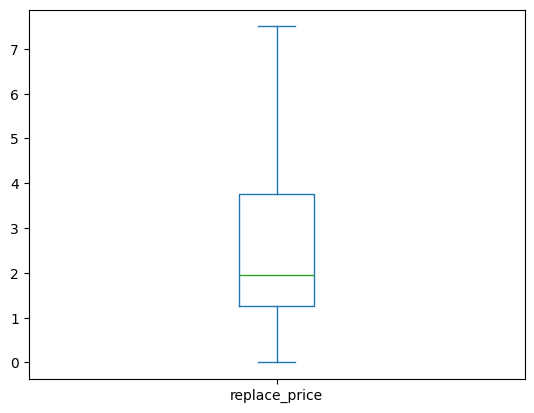

In [53]:
lower,upper = check_outliers(df_ver002['UnitPrice'], 1.5)
print(lower, upper)

mask_lower = df_ver002['UnitPrice'] < lower
mask_lower.sum()

mask_upper = df_ver002['UnitPrice'] > upper
mask_upper.sum()

df_ver002['replace_price'] = df_ver002['UnitPrice'].map(lambda x: upper if x> upper else lower if x < lower else x)
df_ver002['replace_price'].plot.box(whis=1.5)

In [54]:

df_ver003

,CustomerID,InvoiceNo,Date,Time,Total Spent per InvoiceNo,replace_total
0,12346.0,541431,2011-01-18,10:01:00,77183.60,925.5525
1,12347.0,537626,2010-12-07,14:57:00,711.79,711.7900
2,12347.0,542237,2011-01-26,14:30:00,475.39,475.3900
3,12347.0,549222,2011-04-07,10:43:00,636.25,636.2500
4,12347.0,556201,2011-06-09,13:01:00,382.52,382.5200
...,...,...,...,...,...,...
18430,18283.0,579673,2011-11-30,12:59:00,223.61,223.6100
18431,18283.0,580872,2011-12-06,12:02:00,208.00,208.0000
18432,18287.0,554065,2011-05-22,10:39:00,765.28,765.2800
18433,18287.0,570715,2011-10-12,10:23:00,1001.32,925.5525


In [55]:
# Removed the 'Time' column
if 'Time' in df_ver003.columns:
  df_ver003 = df_ver003.drop('Time', axis=1)

df_ver003 #version 3 refined


,CustomerID,InvoiceNo,Date,Total Spent per InvoiceNo,replace_total
0,12346.0,541431,2011-01-18,77183.60,925.5525
1,12347.0,537626,2010-12-07,711.79,711.7900
2,12347.0,542237,2011-01-26,475.39,475.3900
3,12347.0,549222,2011-04-07,636.25,636.2500
4,12347.0,556201,2011-06-09,382.52,382.5200
...,...,...,...,...,...
18430,18283.0,579673,2011-11-30,223.61,223.6100
18431,18283.0,580872,2011-12-06,208.00,208.0000
18432,18287.0,554065,2011-05-22,765.28,765.2800
18433,18287.0,570715,2011-10-12,1001.32,925.5525


In [56]:
# Droping the specified columns
columns_to_drop = ['Quantity', 'UnitPrice', 'Total', 'replace_original_total']
df_ver004 = df_ver002.drop(columns=columns_to_drop, errors='ignore')

df_ver004.head() #version 2 refined

,InvoiceNo,StockCode,Description,CustomerID,Country,Date,Time,replace_quantity,replace_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17850.0,United Kingdom,2010-12-01,08:26:00,6.0,2.55
1,536365,71053,WHITE METAL LANTERN,17850.0,United Kingdom,2010-12-01,08:26:00,6.0,3.39
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,17850.0,United Kingdom,2010-12-01,08:26:00,8.0,2.75
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,17850.0,United Kingdom,2010-12-01,08:26:00,6.0,3.39
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,17850.0,United Kingdom,2010-12-01,08:26:00,6.0,3.39


understand the relationships between customers and the products they purchase

In [57]:
#number of times each customer bought each product.
cross_tab_desc = pd.crosstab(df_ver002['CustomerID'], df_ver002['Description'])
#print("Cross-Tabulation (CustomerID vs. StockCode):\n", cross_tab_desc.head())
cross_tab_desc

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18280.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18281.0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
18282.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [58]:
#Chi-Squared Test of Independence
#significant association between CustomerID and Description
chi2_desc, p_desc, _, _ = chi2_contingency(cross_tab_desc)
print(f"\nChi-Squared Statistic (CustomerID vs. Description): {chi2_desc:.2f}")
print(f"P-value (CustomerID vs. Description): {p_desc:.3f}")

if p_desc < 0.05:
    print("The p-value is less than 0.05, suggesting a statistically significant association between CustomerID and Description.")
else:
    print("The p-value is not less than 0.05, suggesting no statistically significant association between CustomerID and Description (based on this test).")


Chi-Squared Statistic (CustomerID vs. Description): 22343297.33
P-value (CustomerID vs. Description): 0.000
The p-value is less than 0.05, suggesting a statistically significant association between CustomerID and Description.


Frequent Buyers and High-Spending Buyers

# Clustering

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

1. Collect total spend per customer

In [60]:
df_ver002['Total Spent per InvoiceNo'] = df_ver002['Quantity'] * df_ver002['UnitPrice']
customer_spend = df_ver002.groupby('CustomerID')['Total Spent per InvoiceNo'].sum().reset_index()
customer_spend.columns = ['CustomerID', 'TotalSpent']
customer_spend = customer_spend[customer_spend['TotalSpent'] > 0]

2. Normalize the data

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
spend_scaled = scaler.fit_transform(customer_spend[['TotalSpent']])


3. Run K-Means

In [62]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
customer_spend['Cluster'] = kmeans.fit_predict(spend_scaled)
customer_spend.groupby('Cluster').head(3)

,CustomerID,TotalSpent,Cluster
0,12346.0,77183.60,2
1,12347.0,4310.00,0
2,12348.0,1437.24,0
3,12349.0,1457.55,0
55,12415.0,124564.53,1
326,12748.0,32317.32,2
453,12931.0,42055.96,2
1690,14646.0,279138.02,1
1880,14911.0,136275.72,1


4. Scatterplot

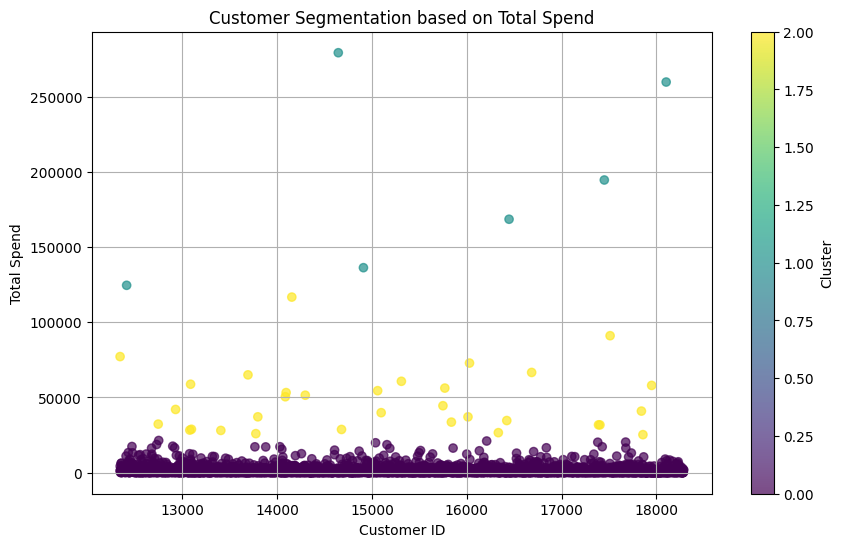

In [63]:
plt.figure(figsize=(10, 6))
plt.scatter(customer_spend['CustomerID'], customer_spend['TotalSpent'],
            c=customer_spend['Cluster'], cmap='viridis', alpha=0.7)
plt.title('Customer Segmentation based on Total Spend')
plt.xlabel('Customer ID')
plt.ylabel('Total Spend')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

5. Bar Chart

<ipython-input-64-a82e4cde589a>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=customer_spend, x='Cluster', y='TotalSpent', estimator='mean', palette='viridis')


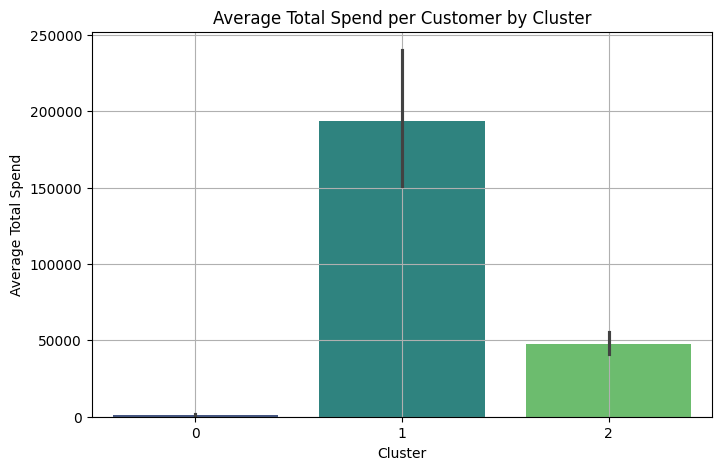

In [64]:
plt.figure(figsize=(8, 5))
sns.barplot(data=customer_spend, x='Cluster', y='TotalSpent', estimator='mean', palette='viridis')
plt.title('Average Total Spend per Customer by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Total Spend')
plt.grid(True)
plt.show()

6. Analyze Clusters

In [65]:
customer_spend.groupby('Cluster')['TotalSpent'].agg(['count', 'mean', 'min', 'max'])

,count,mean,min,max
Cluster,,,,
0,4296,1412.279469,3.75,21429.39
1,6,193776.476667,124564.53,279138.02
2,32,47851.724687,25301.54,116729.63


After applying the K-Means clustering (k=3) to segment customers by the total spend:

Cluster 0: Largest group, which contains 4,285 customers. They consist mostly of low spenders around $1,392.

Cluster 1: Very small, but very high-value segment containing 6 customers. Has an average spend of over 182,000.

Cluster 2: Contains 31 customers, who spend about a moderate to high amount. Has an average spend of around $40,500.

# Seasonal Purchase Trends

1. Convert InvoiceDate to datetime and extract Month

In [66]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.month_name()
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()


2. Count Total Purchases per Month

In [67]:
# Count number of purchases per month
monthly_purchases = df.groupby('Month').size().reset_index(name='TotalPurchases')

# Sort months in calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_purchases['Month'] = pd.Categorical(monthly_purchases['Month'], categories=month_order, ordered=True)
monthly_purchases = monthly_purchases.sort_values('Month')

3. Bar Chart

<ipython-input-68-26167146f996>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_purchases, x='Month', y='TotalPurchases', palette='crest')


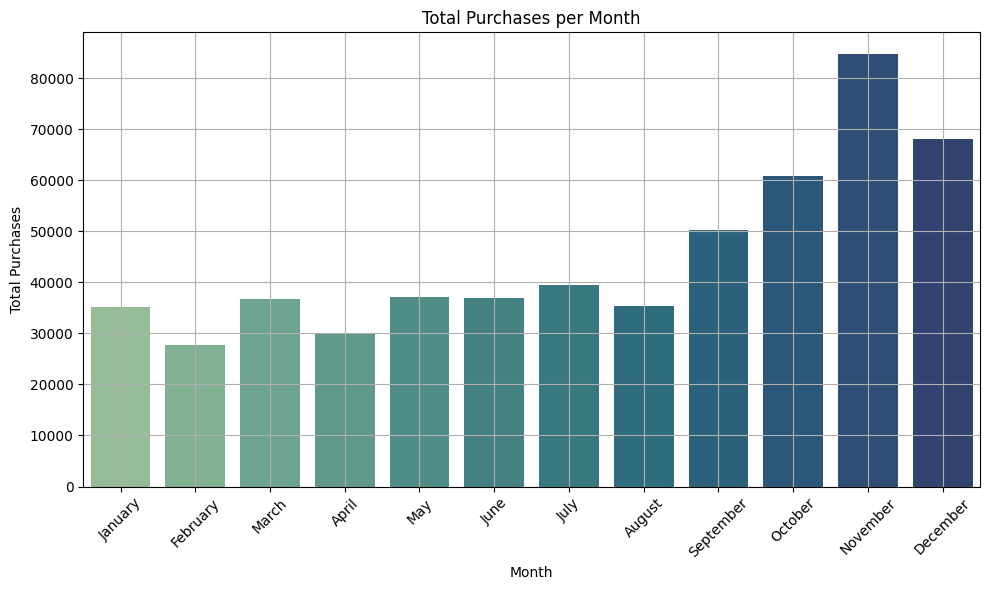

In [68]:
plt.figure(figsize=(10, 6))
sns.barplot(data=monthly_purchases, x='Month', y='TotalPurchases', palette='crest')
plt.title('Total Purchases per Month')
plt.ylabel('Total Purchases')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [69]:
daily_purchases = df.groupby('DayOfWeek').size().reset_index(name='TotalPurchases')

# Order days of the week for better visualization
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_purchases['DayOfWeek'] = pd.Categorical(daily_purchases['DayOfWeek'], categories=day_order, ordered=True)
daily_purchases = daily_purchases.sort_values('DayOfWeek')
daily_purchases

,DayOfWeek,TotalPurchases
1,Monday,95111
4,Tuesday,101808
5,Wednesday,94565
3,Thursday,103857
0,Friday,82193
2,Sunday,64375


**OBSERVATION**
The holiday season (November to December) drives a significant increase in sales, while the post-holiday months (January and February) experience a decline. The period before the holiday season (September and October) also has a significant increase in sales compared to other months of the year.
Notably, the business was closed on Saturdays, which may have impacted overall sales patterns.

**summary of the seasons**
Peak Season: November
Shoulder Seasons: September, October, December
Off-Season: January, February, March, April, August
Other trends: May, June, July; There's a dip in the months of May, June and July, compared to the surrounding months.

Processing description

In [70]:
pwd

'/content'

# Holiday Season Top Products

In [71]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [72]:
desc_category=pd.read_csv('/content/drive/MyDrive/Data mining project/description_category.csv')

**Product Categories highly purchased during Holiday Sesason (October, November, and December)**

In [73]:
desc_category.head()

,Unnamed: 0,0,category,2cat
0,0,WHITE HANGING HEART T-LIGHT HOLDER,This product falls under the category of Decor.,Decor
1,1,WHITE METAL LANTERN,This product can be classified as a Lighting i...,"['Lighting', 'item']"
2,2,CREAM CUPID HEARTS COAT HANGER,This product belongs to the category of Home D...,"['Home', 'Decor']"
3,3,KNITTED UNION FLAG HOT WATER BOTTLE,This product falls under the category of Welln...,Wellness
4,4,RED WOOLLY HOTTIE WHITE HEART.,This product would fall under the category of ...,"['warmth', 'comfort']"


In [74]:
holiday_months = ['October', 'November', 'December']
holiday_df = df[df['Month'].isin(holiday_months)]
holiday_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,December,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,December,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December,Wednesday


In [75]:
top_holiday_products = holiday_df['Description'].value_counts().head(10).index.tolist()  # Get top 10, adjust as needed

In [76]:
top_products_with_categories = pd.merge(
       pd.DataFrame({'Description': top_holiday_products}),  # Using 'Description' here
       desc_category,
       left_on = 'Description',
       right_on = '0',
       how='left'
   )

In [77]:
top_products_with_categories.head()

,Description,Unnamed: 0,0,category,2cat
0,PAPER CHAIN KIT 50'S CHRISTMAS,46,PAPER CHAIN KIT 50'S CHRISTMAS,"This product belongs to the category of ""Decor"".",Decor
1,WHITE HANGING HEART T-LIGHT HOLDER,0,WHITE HANGING HEART T-LIGHT HOLDER,This product falls under the category of Decor.,Decor
2,RABBIT NIGHT LIGHT,3376,RABBIT NIGHT LIGHT,This product falls under the category of Light...,Lighting
3,PAPER CHAIN KIT VINTAGE CHRISTMAS,168,PAPER CHAIN KIT VINTAGE CHRISTMAS,This product would fall under the category of ...,Decor
4,REGENCY CAKESTAND 3 TIER,534,REGENCY CAKESTAND 3 TIER,This product can be classified under the categ...,"[""'Serveware"", 'Stands']"


In [78]:
category_counts = top_products_with_categories['2cat'].value_counts()
category_counts

,count
2cat,
Decor,4
Wellness,4
Lighting,1
"[""'Serveware"", 'Stands']",1


<ipython-input-79-f4e6e52a7820>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')


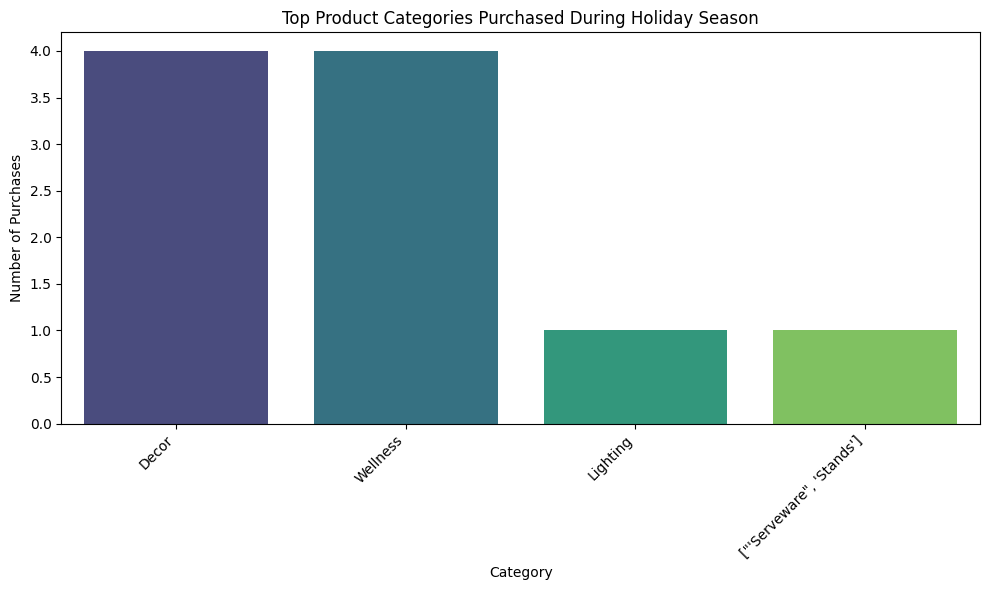

In [79]:
plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.title('Top Product Categories Purchased During Holiday Season')
plt.xlabel('Category')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

**Observation:** Decor, Wellness, lighting and Stand products were in high demand during holiday season

**What is the number of proucts that was actually purchased during this this period.**

In [80]:
df_ver002

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time,Total,replace_original_total,replace_quantity,replace_price,Total Spent per InvoiceNo
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,2010-12-01,08:26:00,15.30,15.30,6.0,2.55,15.30
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34,20.34,6.0,3.39,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,2010-12-01,08:26:00,22.00,22.00,8.0,2.75,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34,20.34,6.0,3.39,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34,20.34,6.0,3.39,20.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,12680.0,France,2011-12-09,12:50:00,10.20,10.20,12.0,0.85,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,France,2011-12-09,12:50:00,12.60,12.60,6.0,2.10,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,France,2011-12-09,12:50:00,16.60,16.60,4.0,4.15,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680.0,France,2011-12-09,12:50:00,16.60,16.60,4.0,4.15,16.60


In [81]:

holiday_months = ['October', 'November', 'December']
#top_categories = ['Decor', 'Wellness', 'Lighting', 'Stand']
top_categories = category_counts.index.tolist()

# Created df_ver005 by merging df_ver002 and desc_category
df_ver005 = pd.merge(df_ver002, desc_category[['0', '2cat']], left_on='Description', right_on='0', how='left')

# Ensure 'Date' is in datetime format
df_ver005['Date'] = pd.to_datetime(df_ver005['Date'])
df_ver005['Month'] = df_ver005['Date'].dt.month_name()

# Dropped specified columns and rename '2cat_x'
df_ver005 = df_ver005.drop(columns=['0_x', '0_y', '2cat_y'], errors='ignore')
df_ver005 = df_ver005.rename(columns={'2cat': 'Category'})
df_ver005.head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time,Total,replace_original_total,replace_quantity,replace_price,Total Spent per InvoiceNo,0,Category,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,2010-12-01,08:26:00,15.30,15.30,6.0,2.55,15.30,WHITE HANGING HEART T-LIGHT HOLDER,Decor,December
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34,20.34,6.0,3.39,20.34,WHITE METAL LANTERN,"['Lighting', 'item']",December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,2010-12-01,08:26:00,22.00,22.00,8.0,2.75,22.00,CREAM CUPID HEARTS COAT HANGER,"['Home', 'Decor']",December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34,20.34,6.0,3.39,20.34,KNITTED UNION FLAG HOT WATER BOTTLE,Wellness,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34,20.34,6.0,3.39,20.34,RED WOOLLY HOTTIE WHITE HEART.,"['warmth', 'comfort']",December


In [82]:
# filter df_ver005
holiday_data = df_ver005[
    df_ver005['Month'].isin(holiday_months) &
    df_ver005['Category'].isin(top_categories)
]
holiday_data.head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time,Total,replace_original_total,replace_quantity,replace_price,Total Spent per InvoiceNo,0,Category,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,2010-12-01,08:26:00,15.30,15.30,6.0,2.55,15.30,WHITE HANGING HEART T-LIGHT HOLDER,Decor,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34,20.34,6.0,3.39,20.34,KNITTED UNION FLAG HOT WATER BOTTLE,Wellness,December
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,7.65,17850.0,United Kingdom,2010-12-01,08:26:00,15.30,15.30,2.0,7.50,15.30,SET 7 BABUSHKA NESTING BOXES,Decor,December
7,536366,22633,HAND WARMER UNION JACK,6,1.85,17850.0,United Kingdom,2010-12-01,08:28:00,11.10,11.10,6.0,1.85,11.10,HAND WARMER UNION JACK,Wellness,December
8,536366,22632,HAND WARMER RED POLKA DOT,6,1.85,17850.0,United Kingdom,2010-12-01,08:28:00,11.10,11.10,6.0,1.85,11.10,HAND WARMER RED POLKA DOT,Wellness,December


In [83]:
#number of products purchased in each category
product_counts_by_category = holiday_data.groupby('Category')['StockCode'].count()
print(product_counts_by_category)

Category
Decor                       52219
Lighting                     5311
Wellness                     8921
["'Serveware", 'Stands']      514
Name: StockCode, dtype: int64


In [84]:
#customers and their countries
customer_country_info = holiday_data[['CustomerID', 'Country']].drop_duplicates()
print(customer_country_info)

       CustomerID         Country
0         17850.0  United Kingdom
9         13047.0  United Kingdom
26        12583.0          France
45        13748.0  United Kingdom
81        15291.0  United Kingdom
...           ...             ...
394957    14569.0  United Kingdom
395365    17405.0  United Kingdom
395439    17144.0  United Kingdom
396230    12713.0         Germany
396357    12680.0          France

[2763 rows x 2 columns]


In [85]:
holiday_data['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Germany', 'Norway',
       'EIRE', 'Switzerland', 'Poland', 'Italy', 'Belgium', 'Lithuania',
       'Japan', 'Iceland', 'Portugal', 'Channel Islands', 'Denmark',
       'Spain', 'Cyprus', 'Sweden', 'Finland', 'Austria', 'Netherlands',
       'Israel', 'Czech Republic', 'USA', 'RSA', 'Singapore', 'Malta',
       'Greece'], dtype=object)

In [86]:
# Count the number of customers per country
customer_counts = customer_country_info['Country'].value_counts()

# Print the number of customers per country
customer_counts


,count
Country,
United Kingdom,2510
Germany,60
France,58
Spain,18
Belgium,15
Portugal,13
Italy,12
Switzerland,9
Finland,8


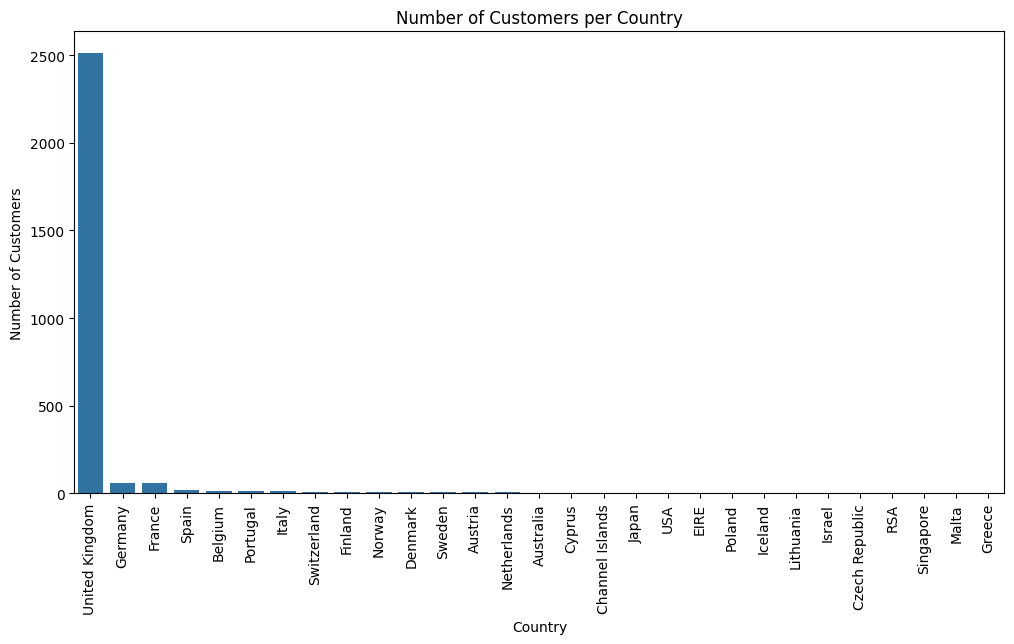

In [87]:
#  a bar plot
plt.figure(figsize=(12, 6))
sns.countplot(x='Country', data=customer_country_info, order=customer_counts.index)
plt.title('Number of Customers per Country')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.show()

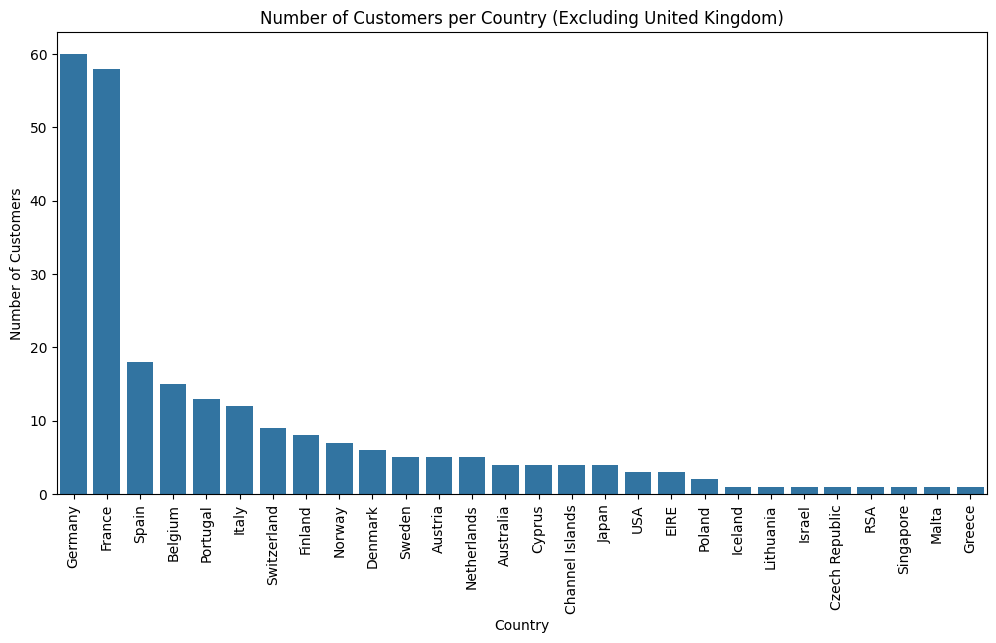

In [88]:
# Exclude United Kingdom
customer_counts_excluded_uk = customer_country_info[customer_country_info['Country'] != 'United Kingdom']['Country'].value_counts()

# a bar plot excluding the United Kingdom
plt.figure(figsize=(12, 6))
sns.countplot(x='Country', data=customer_country_info[customer_country_info['Country'] != 'United Kingdom'], order=customer_counts_excluded_uk.index)
plt.title('Number of Customers per Country (Excluding United Kingdom)')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.show()


Price

In [89]:
#prince range of the dataset
print(f"The range of unit price is: {df_ver005['UnitPrice'].min()} to {df_ver005['UnitPrice'].max()}")



The range of unit price is: 0.0 to 649.5


In [90]:
# Calculate the price range for each category
price_range_by_category = df_ver005.groupby('Category')['UnitPrice'].agg(['min', 'max'])

price_range_by_category


,min,max
Category,,
'Accessories,1.69,2.10
'Bakeware,0.42,0.42
'Decor,0.19,59.95
'Drinkware,0.72,5.79
'Jewelry,4.25,6.95
...,...,...
flowers,2.55,2.55
jewelry,1.25,4.25
product,0.10,15.79


In [91]:
price_range_by_category.describe()

,min,max
count,709.000000,709.000000
mean,3.434824,7.777094
std,25.020833,30.630606
min,0.000000,0.100000
25%,0.500000,1.650000
50%,1.250000,3.290000
75%,2.550000,7.460000
max,649.500000,649.500000


In [92]:
#
# Merge df_ver003 with the necessary columns from df_ver002
df_ver003 = pd.merge(df_ver003, df_ver002[['CustomerID', 'InvoiceNo', 'Country']], on=['CustomerID', 'InvoiceNo'], how='left')
df_ver003


,CustomerID,InvoiceNo,Date,Total Spent per InvoiceNo,replace_total,Country
0,12346.0,541431,2011-01-18,77183.60,925.5525,United Kingdom
1,12347.0,537626,2010-12-07,711.79,711.7900,Iceland
2,12347.0,537626,2010-12-07,711.79,711.7900,Iceland
3,12347.0,537626,2010-12-07,711.79,711.7900,Iceland
4,12347.0,537626,2010-12-07,711.79,711.7900,Iceland
...,...,...,...,...,...,...
397975,18287.0,570715,2011-10-12,1001.32,925.5525,United Kingdom
397976,18287.0,570715,2011-10-12,1001.32,925.5525,United Kingdom
397977,18287.0,573167,2011-10-28,70.68,70.6800,United Kingdom
397978,18287.0,573167,2011-10-28,70.68,70.6800,United Kingdom


In [93]:
customer_spend


,CustomerID,TotalSpent,Cluster
0,12346.0,77183.60,2
1,12347.0,4310.00,0
2,12348.0,1437.24,0
3,12349.0,1457.55,0
4,12350.0,294.40,0
...,...,...,...
4330,18280.0,180.60,0
4331,18281.0,80.82,0
4332,18282.0,178.05,0
4333,18283.0,2088.93,0


In [94]:

# Merge customer_spend with df_ver002 to get the Country for each CustomerID
customer_spend = pd.merge(customer_spend, df_ver002[['CustomerID', 'Country']], on='CustomerID', how='left')

# Display the updated customer_spend DataFrame
customer_spend


,CustomerID,TotalSpent,Cluster,Country
0,12346.0,77183.60,2,United Kingdom
1,12347.0,4310.00,0,Iceland
2,12347.0,4310.00,0,Iceland
3,12347.0,4310.00,0,Iceland
4,12347.0,4310.00,0,Iceland
...,...,...,...,...
396364,18287.0,1837.28,0,United Kingdom
396365,18287.0,1837.28,0,United Kingdom
396366,18287.0,1837.28,0,United Kingdom
396367,18287.0,1837.28,0,United Kingdom


In [95]:
# Drop duplicate CustomerID rows, keeping the first occurrence
customer_spend = customer_spend.drop_duplicates(subset=['CustomerID'], keep='first')

# Display the updated DataFrame without duplicates
customer_spend

,CustomerID,TotalSpent,Cluster,Country
0,12346.0,77183.60,2,United Kingdom
1,12347.0,4310.00,0,Iceland
183,12348.0,1437.24,0,Finland
210,12349.0,1457.55,0,Italy
282,12350.0,294.40,0,Norway
...,...,...,...,...
395516,18280.0,180.60,0,United Kingdom
395526,18281.0,80.82,0,United Kingdom
395533,18282.0,178.05,0,United Kingdom
395545,18283.0,2088.93,0,United Kingdom


In [96]:
# Get unique cluster labels
unique_clusters = customer_spend['Cluster'].unique()

# Create a dictionary to store DataFrames for each cluster
cluster_dfs = {}

# Iterate through unique clusters and create DataFrames
for cluster in unique_clusters:
    cluster_dfs[cluster] = customer_spend[customer_spend['Cluster'] == cluster][['CustomerID', 'TotalSpent', 'Cluster', 'Country']]

# Access DataFrames for each cluster using the cluster label as key
# Example: To access the DataFrame for cluster 0, use cluster_dfs[0]

In [97]:
cluster_1_df = cluster_dfs[1]
cluster_1_df

,CustomerID,TotalSpent,Cluster,Country
3730,12415.0,124564.53,1,Australia
154258,14646.0,279138.02,1,Netherlands
174604,14911.0,136275.72,1,EIRE
274130,16446.0,168472.50,1,United Kingdom
338066,17450.0,194550.79,1,United Kingdom
385588,18102.0,259657.30,1,United Kingdom


In [98]:
#cluster_1_df

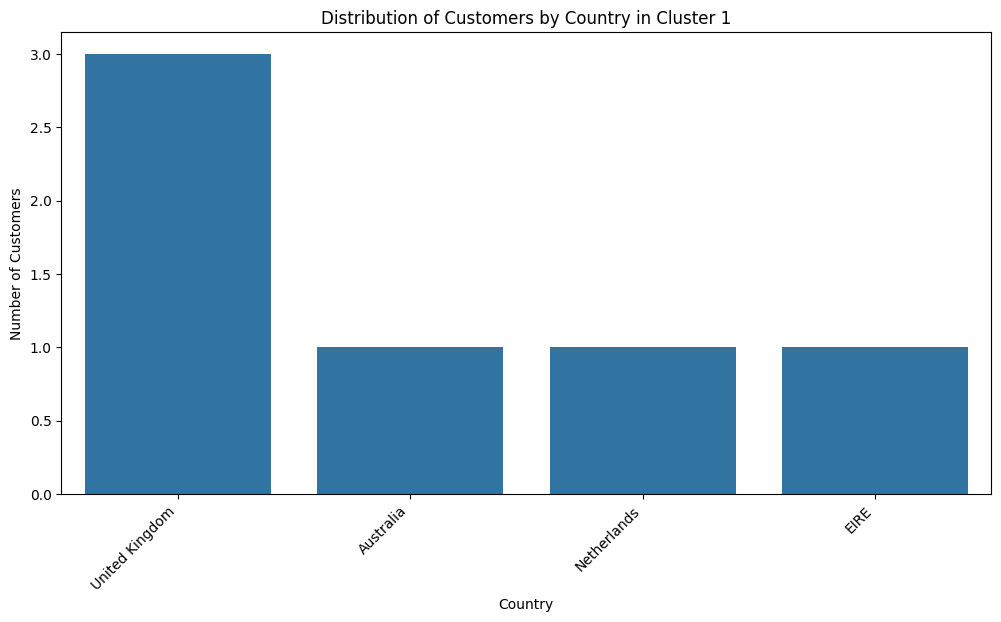

In [99]:


# Assuming cluster_0_df is defined as in the provided code
plt.figure(figsize=(12, 6))
sns.countplot(x='Country', data=cluster_1_df, order=cluster_1_df['Country'].value_counts().index)
plt.title('Distribution of Customers by Country in Cluster 1')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.show()


In [100]:
df_ver005

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Time,Total,replace_original_total,replace_quantity,replace_price,Total Spent per InvoiceNo,0,Category,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,2010-12-01,08:26:00,15.30,15.30,6.0,2.55,15.30,WHITE HANGING HEART T-LIGHT HOLDER,Decor,December
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34,20.34,6.0,3.39,20.34,WHITE METAL LANTERN,"['Lighting', 'item']",December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,2010-12-01,08:26:00,22.00,22.00,8.0,2.75,22.00,CREAM CUPID HEARTS COAT HANGER,"['Home', 'Decor']",December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34,20.34,6.0,3.39,20.34,KNITTED UNION FLAG HOT WATER BOTTLE,Wellness,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34,20.34,6.0,3.39,20.34,RED WOOLLY HOTTIE WHITE HEART.,"['warmth', 'comfort']",December
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,12680.0,France,2011-12-09,12:50:00,10.20,10.20,12.0,0.85,10.20,PACK OF 20 SPACEBOY NAPKINS,"['Party', 'Supplies']",December
396366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,France,2011-12-09,12:50:00,12.60,12.60,6.0,2.10,12.60,CHILDREN'S APRON DOLLY GIRL,"['apron', 'children']",December
396367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,France,2011-12-09,12:50:00,16.60,16.60,4.0,4.15,16.60,CHILDRENS CUTLERY DOLLY GIRL,"['Kitchenware', 'Dining']",December
396368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680.0,France,2011-12-09,12:50:00,16.60,16.60,4.0,4.15,16.60,CHILDRENS CUTLERY CIRCUS PARADE,Kitchenware,December


# Daily Purchase Trends

<ipython-input-101-3b309c157ef4>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily_purchases, x='DayOfWeek', y='Total Spent per InvoiceNo', palette='viridis')


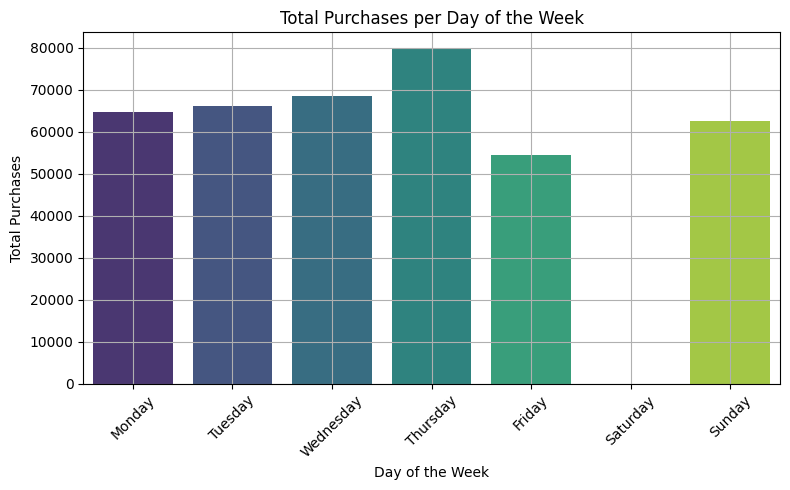

In [101]:
df_ver005['DayOfWeek'] = df_ver005['Date'].dt.day_name()  # Extract day of the week


daily_purchases = df_ver005.groupby('DayOfWeek').size().reset_index(name='Total Spent per InvoiceNo')

# Order days of the week for better visualization
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_purchases['DayOfWeek'] = pd.Categorical(daily_purchases['DayOfWeek'], categories=day_order, ordered=True)
daily_purchases = daily_purchases.sort_values('DayOfWeek')

# a bar plot to visualize daily trends
plt.figure(figsize=(8, 5))
sns.barplot(data=daily_purchases, x='DayOfWeek', y='Total Spent per InvoiceNo', palette='viridis')
plt.title('Total Purchases per Day of the Week')
plt.ylabel('Total Purchases')
plt.xlabel('Day of the Week')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Association Rule Mining

Relationship between products

Relationship between products and customers

(Which products are purchase with which product and what is the probability that a certain product will be purchased base on a purchase of a particular product)

In [102]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [103]:

df_ver006 = df_ver005.drop(columns=['UnitPrice', 'Quantity', 'Total', 0, 'Month'], errors='ignore')
df_ver006.head()


,InvoiceNo,StockCode,Description,CustomerID,Country,Date,Time,replace_original_total,replace_quantity,replace_price,Total Spent per InvoiceNo,0,Category,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17850.0,United Kingdom,2010-12-01,08:26:00,15.30,6.0,2.55,15.30,WHITE HANGING HEART T-LIGHT HOLDER,Decor,Wednesday
1,536365,71053,WHITE METAL LANTERN,17850.0,United Kingdom,2010-12-01,08:26:00,20.34,6.0,3.39,20.34,WHITE METAL LANTERN,"['Lighting', 'item']",Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,17850.0,United Kingdom,2010-12-01,08:26:00,22.00,8.0,2.75,22.00,CREAM CUPID HEARTS COAT HANGER,"['Home', 'Decor']",Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,17850.0,United Kingdom,2010-12-01,08:26:00,20.34,6.0,3.39,20.34,KNITTED UNION FLAG HOT WATER BOTTLE,Wellness,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,17850.0,United Kingdom,2010-12-01,08:26:00,20.34,6.0,3.39,20.34,RED WOOLLY HOTTIE WHITE HEART.,"['warmth', 'comfort']",Wednesday


from matplotlib import pyplot as plt
_df_0['replace_original_total'].plot(kind='hist', bins=20, title='replace_original_total')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['replace_quantity'].plot(kind='hist', bins=20, title='replace_quantity')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['replace_price'].plot(kind='hist', bins=20, title='replace_price')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['Total Spent per InvoiceNo'].plot(kind='hist', bins=20, title='Total Spent per InvoiceNo')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_23['Description'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_23, x='replace_original_total', y='Description', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_24['0'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_24, x='replace_original_total', y='0', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_25['Category'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_25, x='replace_original_total', y='Category', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [104]:
basket = df_ver006.groupby('InvoiceNo')['Description'].apply(list)
basket.head()

,Description
InvoiceNo,
536365,"[WHITE HANGING HEART T-LIGHT HOLDER, WHITE MET..."
536366,"[HAND WARMER UNION JACK, HAND WARMER RED POLKA..."
536367,"[ASSORTED COLOUR BIRD ORNAMENT, POPPY'S PLAYHO..."
536368,"[JAM MAKING SET WITH JARS, RED COAT RACK PARIS..."
536369,[BATH BUILDING BLOCK WORD]


In [105]:
te = TransactionEncoder()
ohe = te.fit(basket).transform(basket)
basket_ohe = pd.DataFrame(ohe, columns=te.columns_)
basket_ohe.head()

,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [106]:
freq = apriori(basket_ohe, min_support=0.01, use_colnames=True)

# 4. rules
rules = association_rules(freq, metric="lift", min_threshold=1)\
          .sort_values(['lift', 'confidence'], ascending=False)



In [107]:
#print(rules[['antecedents','consequents','support','confidence','lift']].head(10))
#rules
rules[['antecedents','consequents','support','confidence','lift']].head(10)

,antecedents,consequents,support,confidence,lift
923,(REGENCY TEA PLATE PINK),"(REGENCY TEA PLATE GREEN , REGENCY TEA PLATE R...",0.010052,0.825893,66.377983
922,"(REGENCY TEA PLATE GREEN , REGENCY TEA PLATE R...",(REGENCY TEA PLATE PINK),0.010052,0.807860,66.377983
924,(REGENCY TEA PLATE GREEN ),"(REGENCY TEA PLATE PINK, REGENCY TEA PLATE ROS...",0.010052,0.685185,64.014382
921,"(REGENCY TEA PLATE PINK, REGENCY TEA PLATE ROS...",(REGENCY TEA PLATE GREEN ),0.010052,0.939086,64.014382
542,(REGENCY TEA PLATE PINK),(REGENCY TEA PLATE GREEN ),0.010975,0.901786,61.471726
543,(REGENCY TEA PLATE GREEN ),(REGENCY TEA PLATE PINK),0.010975,0.748148,61.471726
918,(POPPY'S PLAYHOUSE LIVINGROOM ),"(POPPY'S PLAYHOUSE BEDROOM , POPPY'S PLAYHOUSE...",0.010106,0.738095,53.482846
915,"(POPPY'S PLAYHOUSE BEDROOM , POPPY'S PLAYHOUSE...",(POPPY'S PLAYHOUSE LIVINGROOM ),0.010106,0.732283,53.482846
536,(REGENCY MILK JUG PINK ),(REGENCY SUGAR BOWL GREEN),0.011193,0.757353,52.011496
537,(REGENCY SUGAR BOWL GREEN),(REGENCY MILK JUG PINK ),0.011193,0.768657,52.011496


Observation:
Customers who purchase one type of Regency teacup (pink, green, or roses) are highly likely to buy the others, often completing the set. The pink and green teacups show a particularly strong association, and the overall popularity of Regency teacups is evident from their frequent appearance in top association rules.

customers who purchase products with high lift, support and confidence

In [108]:

# Filter rules for high lift, support, and confidence
high_value_rules = rules[
    (rules['lift'] > rules['lift'].quantile(0.9)) &  # Top 10% lift
    (rules['support'] > rules['support'].quantile(0.7)) &  # Top 30% support
    (rules['confidence'] > rules['confidence'].quantile(0.8))  # Top 20% confidence
]
high_value_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
603,(WOODEN STAR CHRISTMAS SCANDINAVIAN),(WOODEN HEART CHRISTMAS SCANDINAVIAN),0.023526,0.025156,0.017332,0.736721,29.285835,1.0,0.016740,3.702696,0.989124,0.552860,0.729927,0.712853
602,(WOODEN HEART CHRISTMAS SCANDINAVIAN),(WOODEN STAR CHRISTMAS SCANDINAVIAN),0.025156,0.023526,0.017332,0.688985,29.285835,1.0,0.016740,3.139634,0.990778,0.552860,0.681492,0.712853
622,"(REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACU...",(PINK REGENCY TEACUP AND SAUCER),0.020321,0.030209,0.014724,0.724599,23.986049,1.0,0.014110,3.521376,0.978186,0.411229,0.716020,0.606005
628,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.029394,0.030209,0.021190,0.720887,23.863183,1.0,0.020302,3.474549,0.987110,0.551627,0.712193,0.711163
629,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.030209,0.029394,0.021190,0.701439,23.863183,1.0,0.020302,3.250945,0.987939,0.551627,0.692397,0.711163
626,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.023689,0.037544,0.021190,0.894495,23.825164,1.0,0.020301,9.122408,0.981273,0.529172,0.890380,0.729447
631,(GREEN REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.037544,0.023689,0.021190,0.564399,23.825164,1.0,0.020301,2.241298,0.995399,0.529172,0.553830,0.729447
620,"(PINK REGENCY TEACUP AND SAUCER, REGENCY CAKES...",(GREEN REGENCY TEACUP AND SAUCER),0.016789,0.037544,0.014724,0.877023,23.359771,1.0,0.014094,7.826286,0.973536,0.371742,0.872225,0.634604
116,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.030209,0.037544,0.024993,0.827338,22.036408,1.0,0.023859,5.574223,0.984357,0.584498,0.820603,0.746520
117,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.037544,0.030209,0.024993,0.665702,22.036408,1.0,0.023859,2.900976,0.991859,0.584498,0.655288,0.746520


In [109]:
# Extracted customer IDs associated with the antecedents of high-value rules
customer_ids = set()
for _, row in high_value_rules.iterrows():
  antecedents = list(row['antecedents'])
  for antecedent in antecedents:
    customer_ids.update(df_ver006[df_ver006['Description'] == antecedent]['CustomerID'].unique())

# Print or further process the list of customer IDs
print(f"Customers who purchased products with high lift, support and confidence:\n{list(customer_ids)[:10]}")


Customers who purchased products with high lift, support and confidence:
[16384.0, 16386.0, 16389.0, 16398.0, 16404.0, 16409.0, 16411.0, 16415.0, 16419.0, 16426.0]


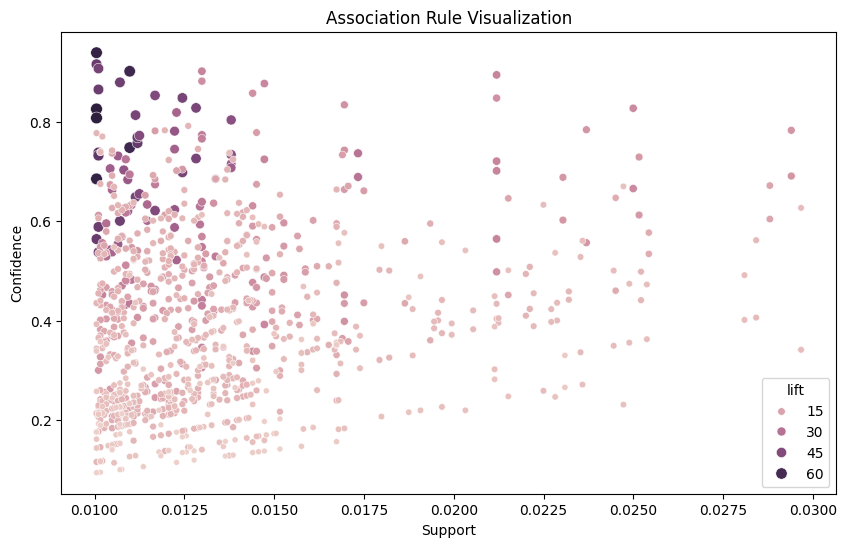

In [110]:
# Assuming 'rules' is your DataFrame of association rules
plt.figure(figsize=(10, 6))  # Adjust size as needed
sns.scatterplot(x='support', y='confidence', data=rules, size='lift', hue='lift')  # Customize columns
plt.title('Association Rule Visualization')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.show()

Observation: * Most of the rules cluster toward low support (around 0.01 to 0.015).
* Higher confidence rules (closer to 1.0) often have a higher lift (dark, bigger dots).
* As support increases (moving right), confidence and lift tend to decrease — meaning rarer itemsets have stronger, more confident associations.

In [111]:
# Get the top 7 rules by lift
top_7_rules = rules.head(7)

# Create a matrix to store lift values, using strings as index/columns
lift_matrix = pd.DataFrame(index=top_7_rules['antecedents'].astype(str),
                           columns=top_7_rules['consequents'].astype(str))
lift_matrix.head()

consequents,"frozenset({'REGENCY TEA PLATE GREEN ', 'REGENCY TEA PLATE ROSES '})",frozenset({'REGENCY TEA PLATE PINK'}),"frozenset({'REGENCY TEA PLATE PINK', 'REGENCY TEA PLATE ROSES '})",frozenset({'REGENCY TEA PLATE GREEN '}),frozenset({'REGENCY TEA PLATE GREEN '}),frozenset({'REGENCY TEA PLATE PINK'}),"frozenset({""POPPY'S PLAYHOUSE BEDROOM "", ""POPPY'S PLAYHOUSE KITCHEN""})"
antecedents,,,,,,,
frozenset({'REGENCY TEA PLATE PINK'}),NaN,NaN,NaN,NaN,NaN,NaN,NaN
"frozenset({'REGENCY TEA PLATE GREEN ', 'REGENCY TEA PLATE ROSES '})",NaN,NaN,NaN,NaN,NaN,NaN,NaN
frozenset({'REGENCY TEA PLATE GREEN '}),NaN,NaN,NaN,NaN,NaN,NaN,NaN
"frozenset({'REGENCY TEA PLATE PINK', 'REGENCY TEA PLATE ROSES '})",NaN,NaN,NaN,NaN,NaN,NaN,NaN
frozenset({'REGENCY TEA PLATE PINK'}),NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [112]:
# Fill the matrix with lift values
for index, row in top_7_rules.iterrows():
    antecedents = str(row['antecedents'])  # Convert to string
    consequents = str(row['consequents']) # Convert to string
    lift = row['lift']
    lift_matrix.loc[antecedents, consequents] = lift

# Replace NaN values with 0 (or another suitable value)
lift_matrix = lift_matrix.fillna(0)
lift_matrix.head()

<ipython-input-112-c60986fd8d6a>:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lift_matrix = lift_matrix.fillna(0)


consequents,"frozenset({'REGENCY TEA PLATE GREEN ', 'REGENCY TEA PLATE ROSES '})",frozenset({'REGENCY TEA PLATE PINK'}),"frozenset({'REGENCY TEA PLATE PINK', 'REGENCY TEA PLATE ROSES '})",frozenset({'REGENCY TEA PLATE GREEN '}),frozenset({'REGENCY TEA PLATE GREEN '}),frozenset({'REGENCY TEA PLATE PINK'}),"frozenset({""POPPY'S PLAYHOUSE BEDROOM "", ""POPPY'S PLAYHOUSE KITCHEN""})"
antecedents,,,,,,,
frozenset({'REGENCY TEA PLATE PINK'}),66.377983,0.000000,0.000000,61.471726,61.471726,0.000000,0.0
"frozenset({'REGENCY TEA PLATE GREEN ', 'REGENCY TEA PLATE ROSES '})",0.000000,66.377983,0.000000,0.000000,0.000000,66.377983,0.0
frozenset({'REGENCY TEA PLATE GREEN '}),0.000000,61.471726,64.014382,0.000000,0.000000,61.471726,0.0
"frozenset({'REGENCY TEA PLATE PINK', 'REGENCY TEA PLATE ROSES '})",0.000000,0.000000,0.000000,64.014382,64.014382,0.000000,0.0
frozenset({'REGENCY TEA PLATE PINK'}),66.377983,0.000000,0.000000,61.471726,61.471726,0.000000,0.0


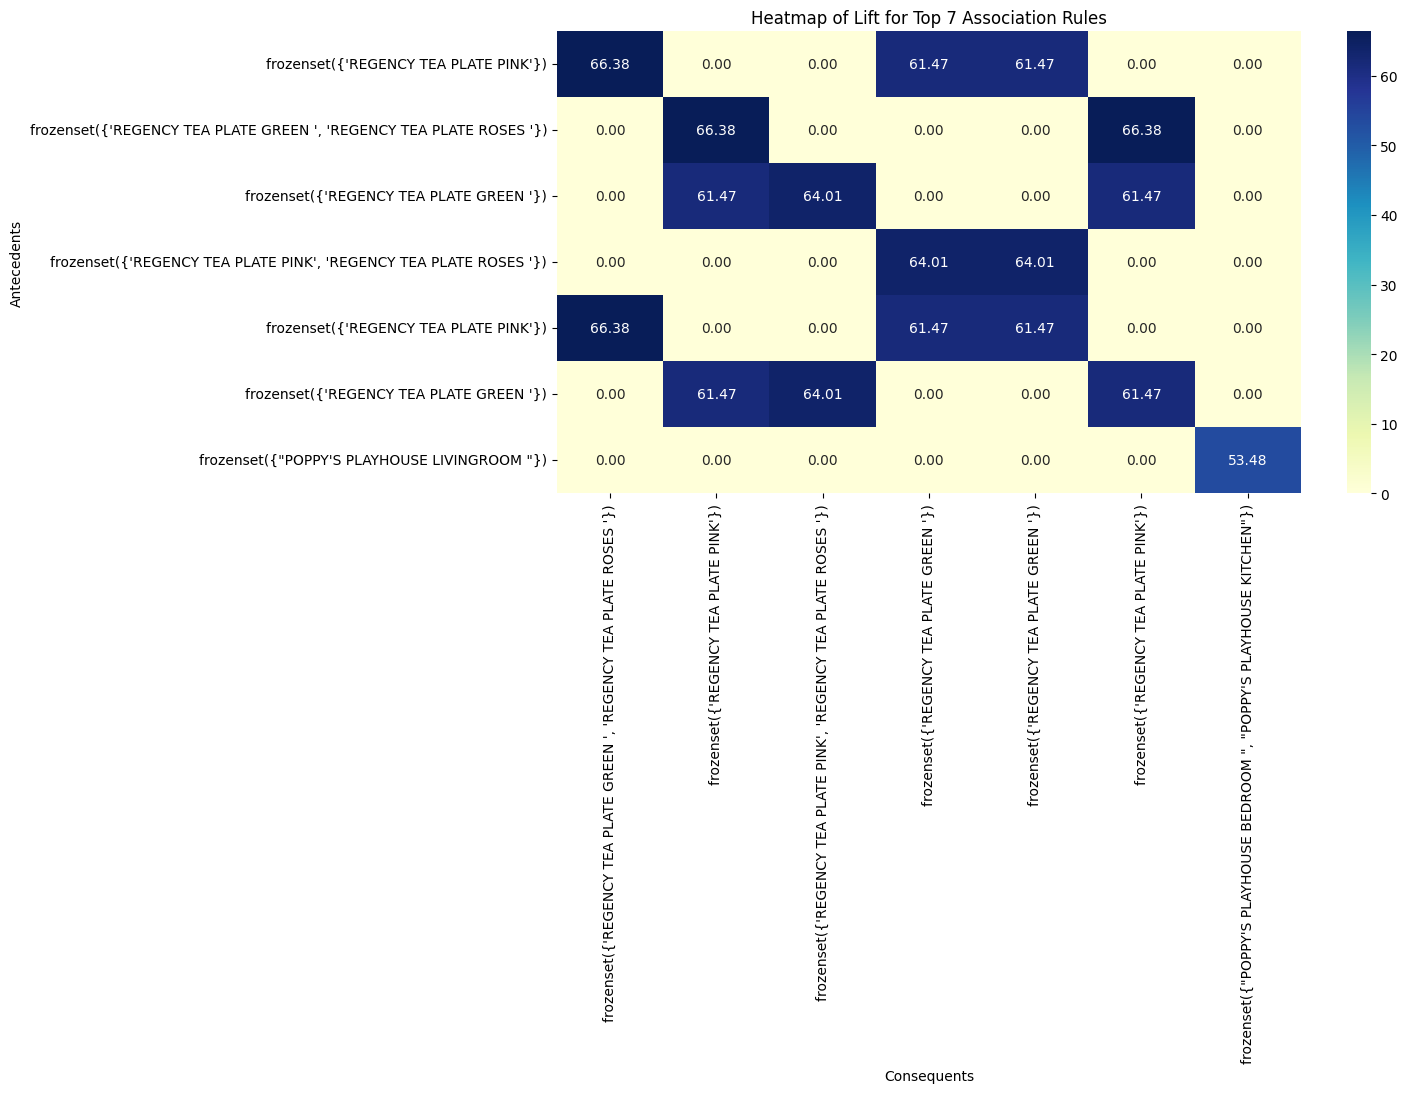

In [113]:
# Create the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(lift_matrix, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Heatmap of Lift for Top 7 Association Rules')
plt.xlabel('Consequents')
plt.ylabel('Antecedents')
plt.show()

Obsevation: The heatmap shows that products from the "REGENCY TEA PLATE" series are very strongly associated with each other — customers often buy them together!
Also, items from "POPPY'S PLAYHOUSE" collections are moderately linked.

In [114]:
# Find the countries associated with the customer IDs
customer_countries = df_ver006[df_ver006['CustomerID'].isin(customer_ids)][['CustomerID', 'Country']].drop_duplicates()

customer_countries.head()


,CustomerID,Country
9,13047.0,United Kingdom
45,13748.0,United Kingdom
81,15291.0,United Kingdom
194,12431.0,Australia
208,17511.0,United Kingdom


In [115]:
# Get the top 10 countries
top_countries = customer_countries['Country'].value_counts().head(10).index

# Filter customer_countries for the top countries
filtered_customers = customer_countries[customer_countries['Country'].isin(top_countries)]
filtered_customers.head()


,CustomerID,Country
9,13047.0,United Kingdom
45,13748.0,United Kingdom
81,15291.0,United Kingdom
208,17511.0,United Kingdom
243,13408.0,United Kingdom


<ipython-input-116-7d431728e9a9>:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')  # Place legend outside the plot


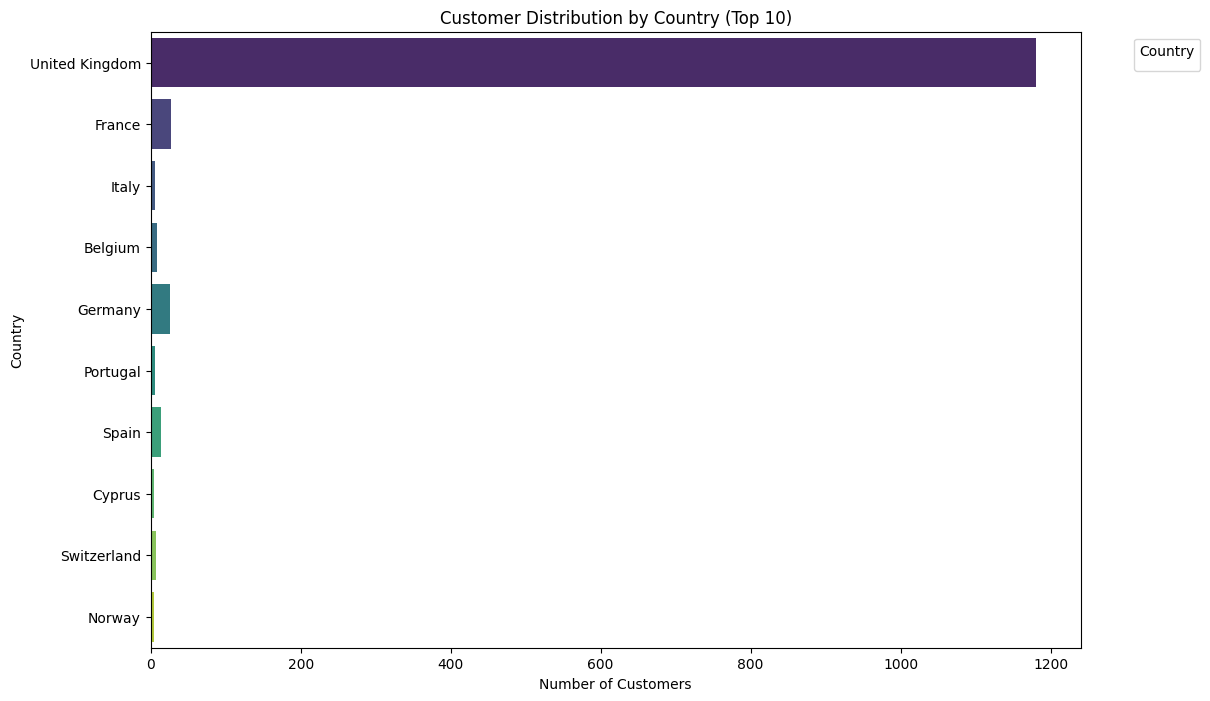

In [116]:
# Create the horizontal bar chart
plt.figure(figsize=(12, 8))
sns.countplot(y='Country', data=filtered_customers, hue='Country', palette='viridis', dodge=False)
plt.title('Customer Distribution by Country (Top 10)')
plt.xlabel('Number of Customers')
plt.ylabel('Country')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')  # Place legend outside the plot
plt.show()

Base on the products these customers bought, what other products can be recommended

In [117]:
def recommend_products(customer_id, rules):
    """
    Recommends products to a customer based on association rules.
    """
    bought_products = set(df_ver006[df_ver006['CustomerID'] == customer_id]['Description'])
    recommendations = set()

    for index, row in rules.iterrows():
        antecedents = set(row['antecedents'])
        consequents = set(row['consequents'])

        if antecedents.issubset(bought_products) and not consequents.issubset(bought_products):
          recommendations.update(consequents)

    return list(recommendations)




In [118]:
# Example usage:
customer_id_to_recommend = 16535  # Example customer ID. Replace with an actual ID
recommendations = recommend_products(customer_id_to_recommend, rules)
#print(f"Recommendations for customer {customer_id_to_recommend}: {recommendations}")


print(f"Recommendations for customer {customer_id_to_recommend}:")
for i, product in enumerate(recommendations):
    print(f"{i+1}. {product}")


Recommendations for customer 16535:
1. PARTY BUNTING
2. WOODEN TREE CHRISTMAS SCANDINAVIAN
3. WOODEN STAR CHRISTMAS SCANDINAVIAN
4. GREEN REGENCY TEACUP AND SAUCER
5. SET OF 3 CAKE TINS PANTRY DESIGN 
6. PINK REGENCY TEACUP AND SAUCER
7. REGENCY TEA PLATE PINK
8. ROSES REGENCY TEACUP AND SAUCER 
9. REGENCY CAKESTAND 3 TIER
10. ASSORTED COLOUR BIRD ORNAMENT
11. REGENCY TEAPOT ROSES 
12. REGENCY TEA PLATE ROSES 
13. WHITE HANGING HEART T-LIGHT HOLDER
14. REGENCY TEA PLATE GREEN 
